In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('data/raw/fadly_data.csv')
df = df.drop(columns='Unnamed: 2')
df = df.drop(columns='ya')
df = df.drop(columns='sudah_review')
df

,clean_text,label
0,oh ternyata bestienya koruptor kakap pertamina...,0.0
1,salah satu kelebihan pertamax oplosan bisa mer...,2.0
2,belum jg win,1.0
3,td pagi buka tiktok ada yg lucu skrg di konoha...,0.0
4,herman khaeron dan amplop pertamina oplosan,0.0
...,...,...
49858,sdh tdk ada takutnya korupsi skr bkn m lg tp s...,0.0
49859,info pente klaseman sementara liga korupsi ind...,0.0
49860,klaseman sementara liga korupsi indonesia,0.0
49861,klaseman korupsi yang beredar harus direvisi b...,0.0


In [3]:
#buang text kosong/Nan
_df = df[df['clean_text'].notna()]
_df = _df[_df['clean_text'].str.strip() != '']
_df = _df.reset_index(drop=True)


print(f'Dataset A -- total: {len(_df)}')
print(_df['label'].value_counts().sort_index())

#_df
#convert_to_csv
#_df.to_csv('fadly_data_proses1.csv', index=False)

Dataset A -- total: 49863
label
0.0    39671
1.0     7811
2.0     2381
Name: count, dtype: int64


In [4]:
#EDA sebelum pre processing
#--- Basic Info ---
df2 = pd.read_csv('data/proses_1/fadly_data_proses1.csv')
print(df2.shape)
print(df2.info())
print(f"Missing values:\n{df2.isnull().sum()}")
print(f"Duplikasi: {df2.duplicated(subset='clean_text').sum()}")

(49863, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49863 entries, 0 to 49862
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   clean_text  49863 non-null  object 
 1   label       49863 non-null  float64
dtypes: float64(1), object(1)
memory usage: 779.2+ KB
None
Missing values:
clean_text    0
label         0
dtype: int64
Duplikasi: 15962


In [5]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import re

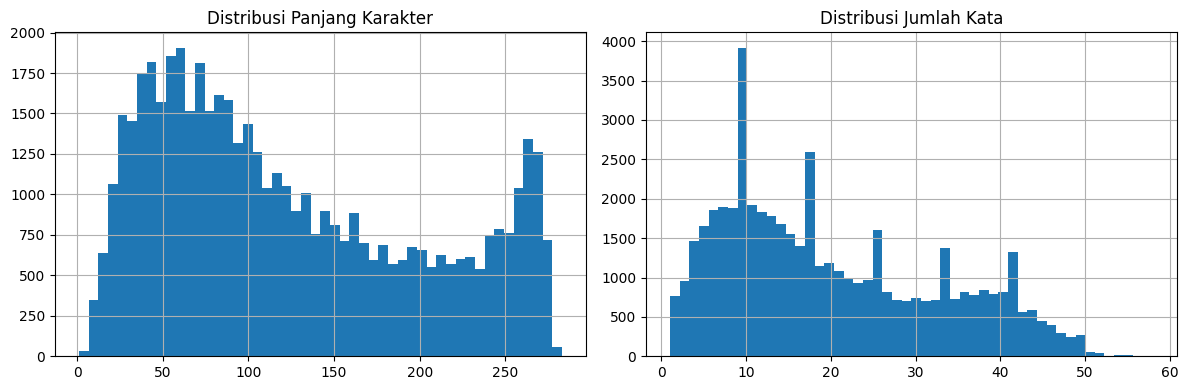

In [6]:
df3=df2
df3['char_len'] = df3['clean_text'].str.len()
df3['word_count'] = df3['clean_text'].str.split().str.len()

fig,axes = plt.subplots(1,2, figsize=(12,4))
df3['char_len'].hist(bins=50, ax=axes[0])
axes[0].set_title('Distribusi Panjang Karakter')
df3['word_count'].hist(bins=50, ax=axes[1])
axes[1].set_title('Distribusi Jumlah Kata')
plt.tight_layout()
plt.show()

In [7]:
df4=df3
print(df4[['char_len','word_count']].describe())

           char_len    word_count
count  49863.000000  49863.000000
mean     123.395865     19.987827
std       77.323050     12.652192
min        1.000000      1.000000
25%       59.000000     10.000000
50%      104.000000     17.000000
75%      184.000000     30.000000
max      283.000000     58.000000


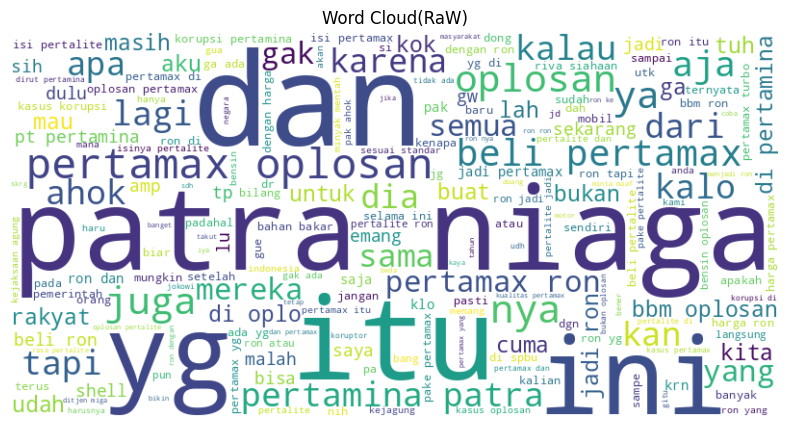

In [8]:
all_text = ' '.join(df4['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10,5))
plt.imshow(wc,interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud(RaW)')
plt.show()

In [ ]:
from src.preprocessing import full_preprocessing

In [ ]:
#preprocessing
df_pre = full_preprocessing(df4, 'clean_text', use_stemming=True)
df_pre.to_csv('preprocessed_dataset_fadly.csv',index=False)

In [ ]:
df_pre = pd.read_csv('data/processed/preprocessed_dataset_fadly.csv')

In [ ]:
df_pre

In [ ]:
#hitung data duplikat
duplikat_count = df_pre['clean_text'].duplicated().sum()
print(f"Jumlah data duplikat: {duplikat_count}")

In [ ]:
# Menghitung data null
null_count = df_pre.isnull().sum()
print(f"Jumlah data null: {null_count}")

In [ ]:
#hapus duplikat
df_pre2 = df_pre.drop_duplicates(subset=["clean_text"])
df_pre2

In [ ]:
df_pre2.to_csv('preprocessed_dataset_fadly.csv', index=False)